# Setup

In [3]:
using Revise
Pkg.activate("../.")
using QuantumDevices
import QuantumToolbox as qt
import DifferentialEquations as DE

using CairoMakie

using Logging

  Activating project at `~/Documents/CodingProjects/QuantumDevices`


# Designing an $\ket{f0}\leftrightarrow\ket{g1}$ Sideband

### Defining The Circuit

In [4]:
transmon_params = Dict{Symbol, Any}()
transmon_params[:name] = "transmon"
transmon_params[:EJ] = 26.96976142643705
transmon_params[:EC] = 0.10283303447280807
transmon_params[:N] = 10
transmon_params[:n_full] = 60

transmon = init_components["transmon"](;transmon_params...)

resonator_params = Dict{Symbol, Any}()
resonator_params[:name] = "resonator"
resonator_params[:Eosc] = 6.228083962082612
resonator_params[:N] = 10

resonator = init_components["resonator"](;resonator_params...)

interactions = [coupling(0.026877206812551357, op(:transmon, :n) * op(:resonator, :a_minus_adag_im))]
circuit = init_circuit([transmon, resonator], interactions; operators_to_add = Dict("nt" => op(:transmon, :n)));

In [5]:
circuit.dressed_order

100-element Vector{Tuple}:
 (0, 0)
 (1, 0)
 (0, 1)
 (2, 0)
 (1, 1)
 (0, 2)
 (3, 0)
 (2, 1)
 (1, 2)
 (4, 0)
 ⋮
 (5, 9)
 (7, 8)
 (9, 7)
 (6, 9)
 (8, 8)
 (7, 9)
 (9, 8)
 (8, 9)
 (9, 9)

## Calibrating Sideband

Basic Parameters:

In [6]:
envelope = "bump_ramp"
amplitude = 0.735
base_freq = circuit.dressed_energies[(0,1)] - circuit.dressed_energies[(2,0)]
phase = 0
delay = 0.0
drive_time = 10
ramp_time = 11
envelope_params = Dict(:k => 2, :ramp_time => ramp_time)


Dict{Symbol, Int64} with 2 entries:
  :ramp_time => 11
  :k         => 2

### Using Floquet to find the resonant frequency

┌ Info: Beginning Floquet Sweep
└ @ QuantumDevices.Dynamics /Users/gavinrockwood/Documents/CodingProjects/QuantumDevices/src/Dynamics/Floquet/Floquet_Sweep.jl:39
Progress: 100%|█████████████████████████████████████████| Time: 0:00:01
┌ Info: Done With Floquet Sweep
└ @ QuantumDevices.Dynamics /Users/gavinrockwood/Documents/CodingProjects/QuantumDevices/src/Dynamics/Floquet/Floquet_Sweep.jl:77
┌ Info: Tracking State
└ @ QuantumDevices.Dynamics /Users/gavinrockwood/Documents/CodingProjects/QuantumDevices/src/Dynamics/Floquet/Floquet_Sweep.jl:80
┌ Info: Resonance at : 2.832303910541878 GHz
└ @ QuantumDevices.Dynamics /Users/gavinrockwood/Documents/CodingProjects/QuantumDevices/src/Dynamics/Drives/ResonanceFinder.jl:64
┌ Info: Approximate Drive Time: 193.04431291199685
└ @ QuantumDevices.Dynamics /Users/gavinrockwood/Documents/CodingProjects/QuantumDevices/src/Dynamics/Drives/ResonanceFinder.jl:65


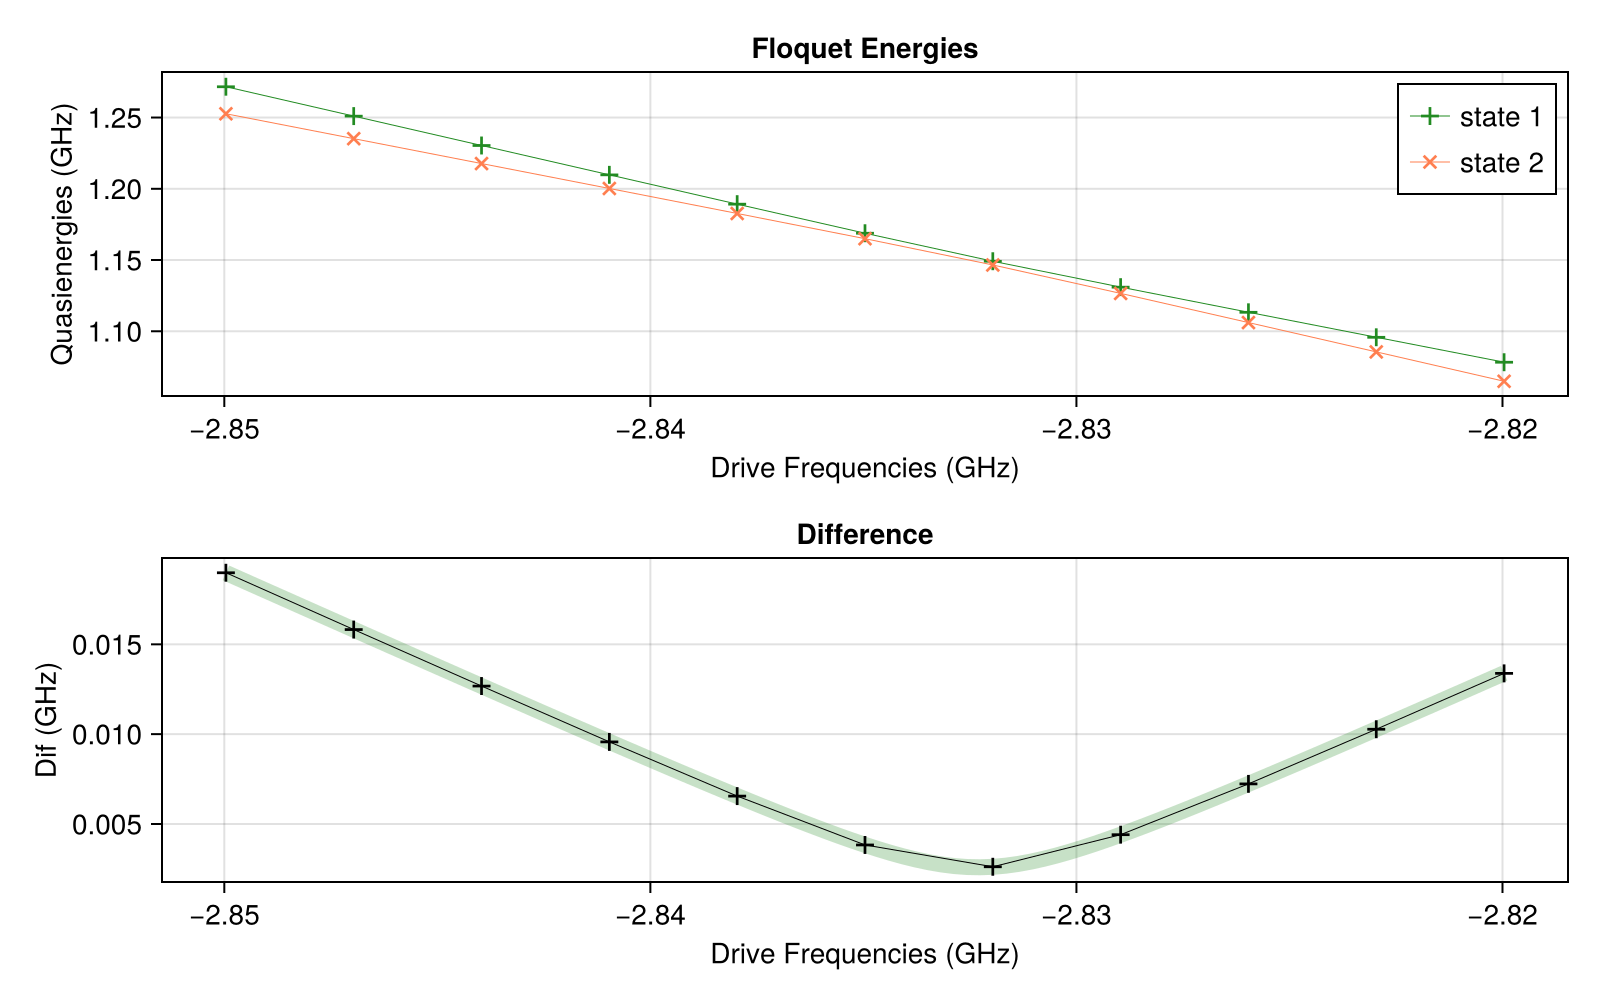

2.832303910541878

In [18]:
reference_states = [circuit.dressed_states[(0,1)], circuit.dressed_states[(2,0)]]
stark_shifts = LinRange(0.02, 0.05, 11)
res_res = find_resonance(circuit.H_op, circuit.ops["nt"], amplitude, base_freq.+stark_shifts, reference_states; show_plot = true)

drive_freq = abs(res_res[1])

### Calibrating Drive Time

#### Using Floquet Landau-Zener

In [38]:
envelope = get_envelope(2.3*ramp_time, "bump_ramp", Dict{Symbol, Any}(:ramp_time => ramp_time))
predicted_flattop_time = get_FLZ_flattop(circuit.H_op, circuit.ops["nt"], drive_freq, amplitude, envelope, ramp_time, circuit.dressed_states[(2,0)], circuit.dressed_states[(0,1)], num_t_samples = 30)#, theta_guess = [0.5, 0.0]);
println("Predicted Flattop Time: ", predicted_flattop_time)

┌ Info: Beginning Floquet Sweep
└ @ QuantumDevices.Dynamics /Users/gavinrockwood/Documents/CodingProjects/QuantumDevices/src/Dynamics/Floquet/Floquet_Sweep.jl:39
Progress: 100%|█████████████████████████████████████████| Time: 0:00:04
┌ Info: Done With Floquet Sweep
└ @ QuantumDevices.Dynamics /Users/gavinrockwood/Documents/CodingProjects/QuantumDevices/src/Dynamics/Floquet/Floquet_Sweep.jl:77
┌ Info: Tracking State
└ @ QuantumDevices.Dynamics /Users/gavinrockwood/Documents/CodingProjects/QuantumDevices/src/Dynamics/Floquet/Floquet_Sweep.jl:80
[sesolve] 100%|███████████████████████████| Time: 0:00:00 ( 2.45 ms/it)


floq_frequency: 0.0025922356851253436
θ: 3.22074363980445, θr: 2.98329068116048
Predicted Flattop Time: 183.16446352127096


In [39]:
drive_time = predicted_flattop_time + 2*ramp_time
H_drive = circuit.H_op + qt.QobjEvo((circuit.ops["nt"], (p,t) -> 0.735 * QuantumDevices.Dynamics.Envelopes.get_envelope(drive_time, "bump_ramp", Dict{Symbol, Any}(:ramp_time => ramp_time))(t) .*sin(2π*drive_freq*t)))
ψ = circuit.dressed_states[(2,0)]
times = collect(0:(1/drive_freq/12):drive_time)

ramp_run = qt.sesolve(2π*H_drive, ψ, times, alg = DE.Vern9(), abstol = 1e-10, reltol = 1e-10)

[sesolve] 100%|███████████████████████████| Time: 0:00:04 ( 0.60 ms/it)


Solution of time evolution
(return code: Success)
--------------------------
num_states = 6974
num_expect = 0
ODE alg.: OrdinaryDiffEqVerner.Vern9{typeof(OrdinaryDiffEqCore.trivial_limiter!), typeof(OrdinaryDiffEqCore.trivial_limiter!), FastBroadcast.Serial, Val{true}}(OrdinaryDiffEqCore.trivial_limiter!, OrdinaryDiffEqCore.trivial_limiter!, FastBroadcast.Serial(), Val{true}())
abstol = 1.0e-10
reltol = 1.0e-10


Final Population in f0: 0.00027770105656438516
Final Population in g1: 0.9997221750842563


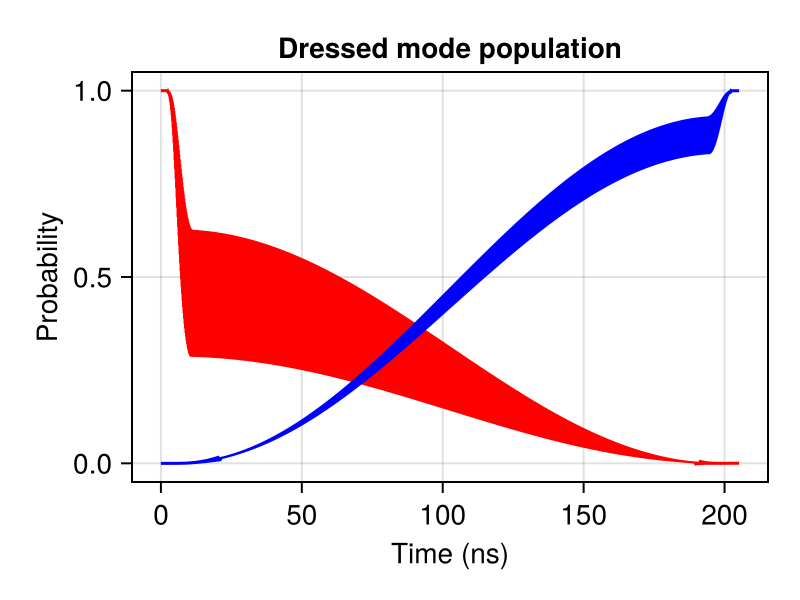

CairoMakie.Screen{IMAGE}


In [40]:
fig = Figure(size = (400, 300))
ax = Axis(fig[1,1], title = "Dressed mode population", xlabel = "Time (ns)", ylabel = "Probability")
indices = 1:length(ramp_run.times)

x = ramp_run.times[indices]
y = [abs(circuit.dressed_states[(2,0)]'*psi)^2 for psi in ramp_run.states[indices]]
lines!(ax, x, y, label = L"|f,0\rangle", color = "red")
println("Final Population in f0: ", y[end])

y = [abs(circuit.dressed_states[(0,1)]'*psi)^2 for psi in ramp_run.states[indices]]
lines!(ax, x, y, label = L"|g,1\rangle", color = "blue")
println("Final Population in g1: ", y[end])

#axislegend(ax, position = :lb)
display(fig)

#### Sweeping Times

In [41]:
psi0 = circuit.dressed_states[(2,0)]
psi_targ = circuit.dressed_states[(0,1)]
to_min(psi) = 1-abs(psi_targ'*psi)^2


envelopeV2(p,t) = amplitude*QuantumDevices.Dynamics.Envelopes.get_envelope(p[1], "bump_ramp", Dict(:ramp_time => ramp_time))(t)*sin(2π*(drive_freq)*t)


drive_op = circuit.H_op+qt.QobjEvo(((circuit.ops["nt"], envelopeV2)))

calibration_res = QuantumDevices.Dynamics.calibrate_drive(drive_op, [res_res[2], res_res[2]+2*ramp_time], psi0, to_min)

┌ Info: Times: [193.04431291199685, 198.54431291199685, 204.04431291199685, 209.54431291199685, 215.04431291199685]
└ @ QuantumDevices.Dynamics /Users/gavinrockwood/Documents/CodingProjects/QuantumDevices/src/Dynamics/Drives/DriveCalibration.jl:37
[sesolve] 100%|███████████████████████████| Time: 0:00:02 ( 0.12 ms/it)
[sesolve] 100%|███████████████████████████| Time: 0:00:02 ( 0.12 ms/it)
[sesolve] 100%|███████████████████████████| Time: 0:00:02 ( 0.12 ms/it)
[sesolve] 100%|███████████████████████████| Time: 0:00:02 ( 0.12 ms/it)
[sesolve] 100%|███████████████████████████| Time: 0:00:02 ( 0.12 ms/it)
┌ Info: Iter 1 mins: Any[0.008688271297880745, 0.002471154301790346, 0.0002449282548143694, 0.002027446093827767, 0.007804369439830983]
└ @ QuantumDevices.Dynamics /Users/gavinrockwood/Documents/CodingProjects/QuantumDevices/src/Dynamics/Drives/DriveCalibration.jl:48
┌ Info: Minimum Beats Tolerance: 0.0002449282548143694
└ @ QuantumDevices.Dynamics /Users/gavinrockwood/Documents/CodingProj

2-element Vector{Float64}:
 204.04431291199685
   0.0002449282548143694

In [44]:
H_drive = circuit.H_op + qt.QobjEvo((circuit.ops["nt"], (p,t) -> 0.735 * QuantumDevices.Dynamics.Envelopes.get_envelope(calibration_res[1], "bump_ramp", Dict{Symbol, Any}(:ramp_time => ramp_time))(t) .*sin(2π*drive_freq*t)))
ψ = circuit.dressed_states[(2,0)]
times = collect(0:(1/drive_freq/12):calibration_res[1])

ramp_runV2 = qt.sesolve(2π*H_drive, ψ, times, alg = DE.Vern9(), abstol = 1e-10, reltol = 1e-10)

[sesolve] 100%|███████████████████████████| Time: 0:00:04 ( 0.61 ms/it)


Solution of time evolution
(return code: Success)
--------------------------
num_states = 6935
num_expect = 0
ODE alg.: OrdinaryDiffEqVerner.Vern9{typeof(OrdinaryDiffEqCore.trivial_limiter!), typeof(OrdinaryDiffEqCore.trivial_limiter!), FastBroadcast.Serial, Val{true}}(OrdinaryDiffEqCore.trivial_limiter!, OrdinaryDiffEqCore.trivial_limiter!, FastBroadcast.Serial(), Val{true}())
abstol = 1.0e-10
reltol = 1.0e-10


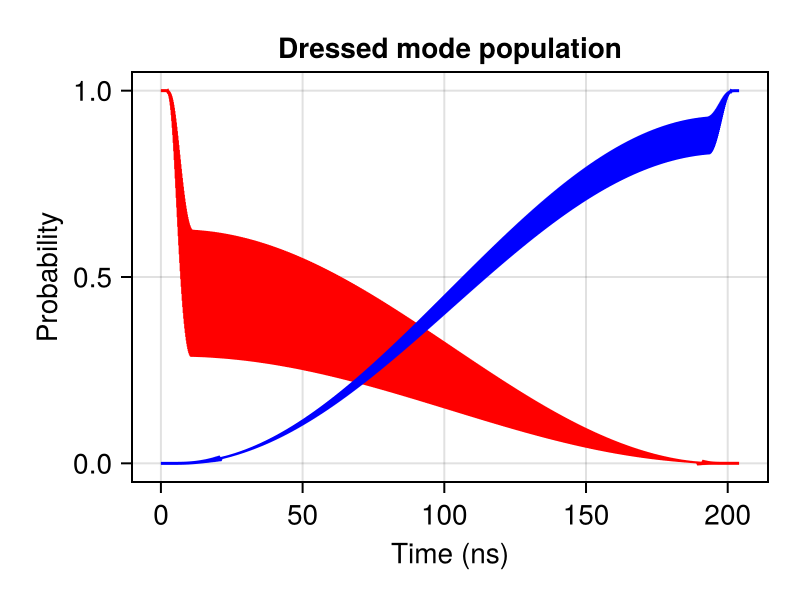

Final Population in f0: 0.00023979154610632221
Final Population in g1: 0.9997600912346066


CairoMakie.Screen{IMAGE}


In [45]:
fig = Figure(size = (400, 300))
ax = Axis(fig[1,1], title = "Dressed mode population", xlabel = "Time (ns)", ylabel = "Probability")
indices = 1:length(ramp_runV2.times)

x = ramp_runV2.times[indices]
y = [abs(circuit.dressed_states[(2,0)]'*psi)^2 for psi in ramp_runV2.states[indices]]
lines!(ax, x, y, label = L"|f,0\rangle", color = "red")
println("Final Population in f0: ", y[end])

y = [abs(circuit.dressed_states[(0,1)]'*psi)^2 for psi in ramp_runV2.states[indices]]
lines!(ax, x, y, label = L"|g,1\rangle", color = "blue")
println("Final Population in g1: ", y[end])

#axislegend(ax, position = :lb)
display(fig)